# LSTM — Long Short-Term Memory Model

- Part A: Hidden size sensitivity — expanding window, three hidden sizes compared

**Standardisation**  
At each forecast origin, the input features and the target variable are standardized using the mean and standard deviation computed exclusively from the training days available at that origin. The same parameters are then applied to the prediction input before inference, and predictions are back-transformed to EUR/MWh using the same per-origin statistics. This ensures that no information from the test period influences the scaling step.

**Architecture**  
Two LSTM layers stacked on top of each other with dropout in between, followed by a fully connected layer that outputs a single vector of size 96 representing the 96 prices of the target day. The network is trained from scratch at each forecast horizon using all available training data.

# Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# global seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")  # CPU only
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("Imports OK")

PyTorch version: 2.11.0+cpu
Device: cpu
Imports OK


# Step 2 - Configuration

In [2]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals  = 96     # quarter-hours per day
nfeatures   = 7      # input features
seq_days     = 7     # LSTM looks back 7 days (one full week)
random_state = 42

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]
target = "price_eur_mwh"

# hidden sizes to compare
hidden_sizes  = [64, 5, 4]

num_layers  = 2     # stacked LSTM layers
dropout     = 0.2   # applied between the two LSTM layers to reduce overfitting

# training hyperparameters
learning_rate = 0.001
max_epochs    = 50
batch_size    = 16
patience      = 10   # early stopping patience

input_size  = nintervals * nfeatures   # 672 - one week of 96-interval days, 7 features
output_size = nintervals               # 96  - all quarter-hourly prices of the target day

print(f"Hidden sizes to compare: {hidden_sizes}")
print(f"Sequence length: {seq_days} days")
print(f"Input size per step: {input_size}")
print(f"Output size: {output_size}")

Hidden sizes to compare: [64, 5, 4]
Sequence length: 7 days
Input size per step: 672
Output size: 96


# Step 3 - Load Data

In [3]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

# reshape to day-level arrays: one row per day
X_days = np.zeros((n_total, nintervals, nfeatures))
y_days = np.zeros((n_total, nintervals))

for i, day in enumerate(all_days):
    day_df   = df[df["timestamp"].dt.date == day].sort_values("timestamp")
    X_days[i] = day_df[features].values   # (96, 7)
    y_days[i] = day_df[target].values     # (96,)

print(f"X_days : {X_days.shape} - y_days : {y_days.shape}")
print(f"Train : {n_train} days - Test : {n_test} days - Total : {n_total} days")

X_days : (144, 96, 7) - y_days : (144, 96)
Train : 100 days - Test : 44 days - Total : 144 days


# Step 4 - LSTM Architecture
Two stacked LSTM layers with dropout between them. The output of the second layer at the final time step is passed to a fully connected layer that
produces all 96 quarter-hourly prices for the target day in a single forward pass.

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step   = lstm_out[:, -1, :]   # take only the final time step
        return self.fc(last_step)

print("LSTMForecaster class defined")

LSTMForecaster class defined


# Step 5 - Sequence Builder
Converts day-level arrays into overlapping input/output sequences.Each sequence consists of seq_days consecutive days of features (the input)
and the quarter-hourly prices of the following day (the target).This function is called inside the forecast loop after per-origin standardization, so it always operates on correctly scaled data.

In [5]:
# Parameters
# X_norm: normalised feature array, shape (n_days, nintervals, nfeatures)
# y_norm: normalised target array,  shape (n_days, nintervals) ,length is forecast_day_idx - does NOT include the forecast day
# seq_days: number of look-back days per sequence
# Returns
# X_seq: shape (n_sequences, seq_days, input_size) model input
# y_seq: shape (n_sequences, nintervals)  training targets

def build_sequences(X_norm, y_norm, seq_days):
    n_days = len(y_norm)   # number of days with a known target
    X_seq, y_seq = [], []
    for d in range(seq_days, n_days):
        seq = X_norm[d - seq_days:d]      # (seq_days, nintervals, nfeatures)
        X_seq.append(seq.reshape(seq_days, -1))   # flatten to (seq_days, 672)
        y_seq.append(y_norm[d])           # (nintervals,)
    return np.array(X_seq), np.array(y_seq)


print("build_sequences function defined")

build_sequences function defined


# Step 6 - Train and Evaluate All Hidden Sizes
For each hidden size, the LSTM model is retrained from scratch at every forecast origin using all training sequences available up to that point. 

At each forecast origin, the input features and target values are standardized using only the training data available at that origin. The same scaling parameters are then applied to the prediction input, and the predicted values are transformed back to the original EUR/MWh scale before evaluation. This prevents data leakage and is important because neural networks are sensitive to the scale of input and target variables. 

The last 10% of the available training sequences are used as a validation set. Training stops early if the validation loss does not improve for a predefined number of epochs, controlled by the `patience` parameter. After training, the model state with the lowest validation loss is restored and used for prediction. 

To ensure reproducibility, `torch.manual_seed` is called before each model is initialized. In addition, a fixed `torch.Generator` object is passed to the `DataLoader`, so the order of shuffled training batches remains consistent across runs.

In [6]:
results   = {}   # stores evaluation scores
all_preds = {}   # stores forecast matrix

# ground-truth prices for the test period in EUR/MWh
y_test_orig = y_days[n_train:].copy()   # (44, 96) raw EUR/MWh, used for final scoring

for hidden_size in hidden_sizes:
    config_name = f"hidden_size = {hidden_size}"
    print(f"\n  LSTM {config_name}")

    # empty matrix to collect predictions for all test days
    lstm_predictions = np.zeros((n_test, nintervals))

    # loop over all test days
    for i in range(n_test):
        forecast_day_idx = n_train + i   # absolute day index of the day being forecast

        # per-origin standardisation
        # compute mean and std from training days available at this origin only
        X_tr_raw = X_days[:forecast_day_idx]   # (forecast_day_idx, 96, 7)
        y_tr_raw = y_days[:forecast_day_idx]   # (forecast_day_idx, 96)

        offset_X = X_tr_raw.reshape(-1, nfeatures).mean(axis=0)
        scale_X  = X_tr_raw.reshape(-1, nfeatures).std(axis=0)
        scale_X[scale_X == 0] = 1.0

        offset_y = float(y_tr_raw.mean())
        scale_y  = float(y_tr_raw.std())
        if scale_y == 0:
            scale_y = 1.0

        # normalize: include forecast day in X so the prediction input is correctly scaled
        X_norm_i = (X_days[:forecast_day_idx + 1] - offset_X) / scale_X
        y_norm_i = (y_days[:forecast_day_idx]     - offset_y) / scale_y

        # build sequences from the normalized arrays
        X_seq_i, y_seq_i = build_sequences(X_norm_i, y_norm_i, seq_days)

        # split last 10% into validation set for early stopping
        n_val  = max(1, int(0.1 * len(X_seq_i)))
        X_val  = torch.tensor(X_seq_i[-n_val:], dtype=torch.float32).to(device)
        y_val  = torch.tensor(y_seq_i[-n_val:], dtype=torch.float32).to(device)
        X_tr   = torch.tensor(X_seq_i[:-n_val], dtype=torch.float32).to(device)
        y_tr   = torch.tensor(y_seq_i[:-n_val], dtype=torch.float32).to(device)

        # fixed generator ensures shuffle order is reproducible across runs
        g = torch.Generator()
        g.manual_seed(random_state)
        train_loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=batch_size,
            shuffle=True,
            generator=g,
        )

        # re-seed before each model instantiation for identical weight initialization
        torch.manual_seed(random_state)
        model = LSTMForecaster(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            output_size = output_size,
            dropout     = dropout,
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        # early stopping state
        best_val_loss    = float("inf")
        patience_counter = 0
        best_state       = None

        for epoch in range(max_epochs):
            # training pass
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()

            # validation pass
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val), y_val).item()

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                patience_counter = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break

        # restore best model and predict
        model.load_state_dict(best_state)
        model.eval()

        # prediction input: the 7 days immediately before the forecast day
        X_pred = X_norm_i[forecast_day_idx - seq_days : forecast_day_idx]
        X_pred = torch.tensor(
            X_pred.reshape(1, seq_days, -1),
            dtype=torch.float32,
        ).to(device)

        with torch.no_grad():
            pred_sc = model(X_pred).cpu().numpy().squeeze()   # (96,) normalised

        # back-transform using this origin's scaling parameters
        lstm_predictions[i] = pred_sc * scale_y + offset_y

        if (i + 1) % 10 == 0 or i == 0:
            print(f"  Day {i+1:>2d}/44 done (trained on {forecast_day_idx} days)")

    # evaluate against original EUR/MWh prices
    errors = y_test_orig - lstm_predictions
    mae    = float(np.mean(np.abs(errors)))
    rmse   = float(np.sqrt(np.mean(errors ** 2)))

    results[config_name]   = {"MAE": round(mae, 4), "RMSE": round(rmse, 4)}
    all_preds[config_name] = lstm_predictions.copy()
    print(f"  -> MAE: {mae:.4f}  RMSE: {rmse:.4f} EUR/MWh")

print("\nAll hidden sizes done")


  LSTM hidden_size = 64
  Day  1/44 done (trained on 100 days)
  Day 10/44 done (trained on 109 days)
  Day 20/44 done (trained on 119 days)
  Day 30/44 done (trained on 129 days)
  Day 40/44 done (trained on 139 days)
  -> MAE: 20.6375  RMSE: 28.5119 EUR/MWh

  LSTM hidden_size = 5
  Day  1/44 done (trained on 100 days)
  Day 10/44 done (trained on 109 days)
  Day 20/44 done (trained on 119 days)
  Day 30/44 done (trained on 129 days)
  Day 40/44 done (trained on 139 days)
  -> MAE: 22.3171  RMSE: 31.2840 EUR/MWh

  LSTM hidden_size = 4
  Day  1/44 done (trained on 100 days)
  Day 10/44 done (trained on 109 days)
  Day 20/44 done (trained on 119 days)
  Day 30/44 done (trained on 129 days)
  Day 40/44 done (trained on 139 days)
  -> MAE: 23.2876  RMSE: 31.3068 EUR/MWh

All hidden sizes done


# Step 7 - Comparison Table

In [7]:
print("LSTM — Hidden Size Comparison")
print(f"  {'Configuration':<25} {'MAE':>8} {'RMSE':>8}")
print()
for name, r in results.items():
    print(f"  {name:<25} {r['MAE']:>8.4f} {r['RMSE']:>8.4f}")
print()

best = min(results, key=lambda x: results[x]["MAE"])
print(f"\nBest configuration (lowest MAE): {best}")

LSTM — Hidden Size Comparison
  Configuration                  MAE     RMSE

  hidden_size = 64           20.6375  28.5119
  hidden_size = 5            22.3171  31.2840
  hidden_size = 4            23.2876  31.3068


Best configuration (lowest MAE): hidden_size = 64


# Step 8 - Forecast Plot (Best Configuration)
Actual vs forecast prices for the first 7 days of the evaluation period (16–22 January 2026), using the best hidden size.

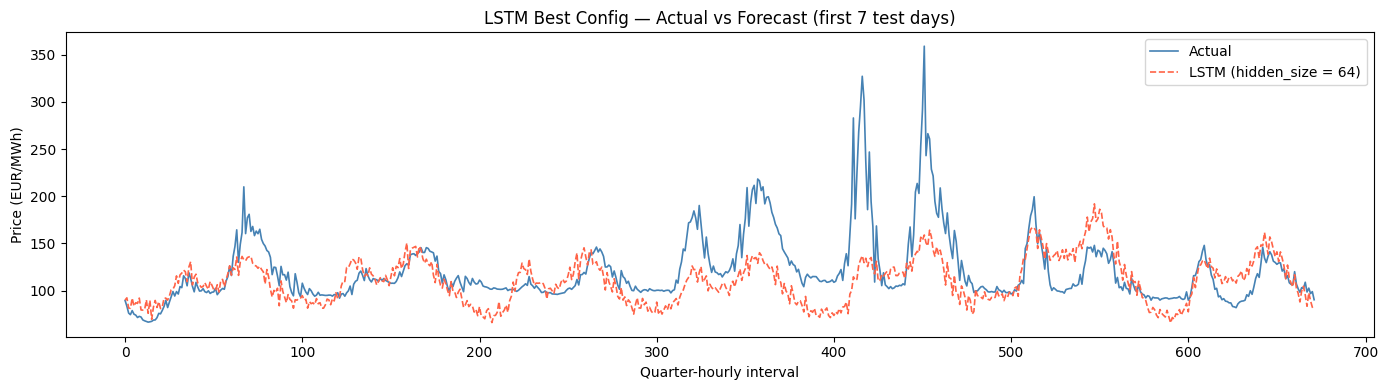

Plot saved


In [8]:
best_pred = all_preds[best]
n_plot    = 7 * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot],
        label="Actual", linewidth=1.2, color="steelblue")
ax.plot(best_pred.flatten()[:n_plot],
        label=f"LSTM ({best})", linewidth=1.2, color="tomato", linestyle="--")
ax.set_title("LSTM Best Config — Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "LSTM_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

# Step 9 - Save Results

In [9]:
best_result = results[best]

lstm_dict = {
    # identification
    "model_name"  : "LSTM",
    # best configuration — hidden size with lowest MAE
    "best_config" : best,
    "all_results" : results,
    "prediction"  : all_preds[best],   # (n_test, 96) EUR/MWh
    "mae"         : best_result["MAE"],
    "rmse"        : best_result["RMSE"],
    # ground truth and metadata
    "y_test"      : y_test_orig,       # (n_test, 96) EUR/MWh
    "test_days"   : [str(d) for d in test_days],
}

with open(output_dir / "LSTM.pkl", "wb") as f:
    pickle.dump([lstm_dict], f)

print(f"Saved: {output_dir / 'LSTM.pkl'}")
print("LSTM.ipynb complete")

Saved: ..\data\results\LSTM.pkl
LSTM.ipynb complete
